# Traditional ML Stack Backtest Notebook (10B+ Universe)

This notebook runs the traditional stack on a `10B+` US equity universe:
- RF classifier
- RF regressor
- autoencoder familiarity

It is organized as a research workflow rather than a single backtest script.
The early sections build the universe, labels, models, and scored panel. The later sections compare deterministic rules so we can see where the edge is coming from.


## Research Roadmap

Implemented now:
- `A-D`: build the 10B+ universe, labels, traditional stack models, and scored panel
- `H-I`: compare deterministic score-family rules (`raw3` vs `raw_pct6`) under fixed execution logic
- `J`: run paper-inspired tests for ranking, signal roles, timing, and robustness

How to read the notebook:
- `A-D` define the training universe, labeling recipe, and model stack
- `E-G` freeze the execution assumptions and benchmark setup
- `H-J` evaluate what parts of the stack are actually useful out of sample


## A) Setup And Config


In [ ]:
import os
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import django
from django.apps import apps
from django.db.models import Q

# Jupyter kernels often run an async loop; allow sync ORM calls in this notebook context.
os.environ.setdefault("DJANGO_ALLOW_ASYNC_UNSAFE", "true")
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "settings")
if not apps.ready:
    django.setup()

from fmp.models import Symbol
from fmp.workflows import run_scoring_data_refresh_from_fmp
from features.feature_builders import build_price_technical_features
from features.views import _load_adjusted_prices
from pipeline.api import (
    build_fundamental_dataframe,
    build_macro_dataframe,
    build_label_dataframe,
)
from data.preparation import MLDatasetConfig, prepare_ml_dataset
from backtest.raw_stack import (
    StrategyCase,
    ProbabilityColumnConfig,
    enrich_scored_panel,
    make_backtest_panel,
    make_exec_cfg,
    run_case as run_eval_case,
    strategy_diagnostics,
    build_anchored_fold,
)
from ml.rl.common import RLConfig, make_rebalance_mask, backtest_strategy_per_stock_discrete
from backtest.latest import run_panel_prediction_custom, make_autoencoder_familiarity_predictor
from backtest.backtest import backtest_panel
from backtest.strategies.benchmark import BuyAndHoldEqualWeightStrategy
from pipeline.universe_selection import DEFAULT_US_EXCHANGES, resolve_symbol_universe
from trading.live_trade import resolve_fmp_api_key

pd.set_option("display.max_columns", 200)


def _build_technical_dataframe_from_django(
    *,
    symbols,
    start_date=None,
    end_date=None,
):
    start_ts = pd.Timestamp(start_date) if start_date is not None else None
    end_ts = pd.Timestamp(end_date) if end_date is not None else None

    frames = []
    feature_cols = []

    for sym in symbols:
        code = str(sym).strip().upper()
        if not code:
            continue

        symbol_obj = Symbol.objects.filter(symbol__iexact=code).only("id", "symbol").first()
        if symbol_obj is None:
            continue

        df_prices = _load_adjusted_prices(
            symbol_obj,
            start_ts.date() if start_ts is not None else None,
            end_ts.date() if end_ts is not None else None,
        )
        if df_prices.empty:
            continue

        built = build_price_technical_features(code, df_prices)
        if built.df.empty:
            continue

        px = df_prices[["open", "high", "low", "close", "volume"]].copy()
        px["symbol"] = code
        px = px.reset_index().set_index(["date", "symbol"]).sort_index()

        panel = px.join(built.df[built.feature_cols], how="left")
        frames.append(panel)

        for col in built.feature_cols:
            if col not in feature_cols:
                feature_cols.append(col)

    if not frames:
        empty_index = pd.MultiIndex(levels=[[], []], codes=[[], []], names=["date", "symbol"])
        return pd.DataFrame(index=empty_index), feature_cols

    technical_df = pd.concat(frames, axis=0).sort_index()
    if technical_df.index.has_duplicates:
        technical_df = technical_df[~technical_df.index.duplicated(keep="last")]

    return technical_df, feature_cols


# ------------------------------
# Global Config (single source of truth)
# ------------------------------
APP_CFG = {
    "dates": {
        "train_cutoff": "2020-12-31",
        "bt_start": "2021-01-01",
        "bt_end": "2025-12-31",
        "data_start": "2005-01-01",
        "score_start": "2020-01-01",
    },
    "universe": {
        "country": "US",
        "exchanges": list(DEFAULT_US_EXCHANGES),
        "min_market_cap": 10_000_000_000.0,  # 10B+ universe
        "exclude_pooled_vehicles": True,
        "size": None,  # None => full DB-matched universe
    },
    "runtime": {
        "cache_enabled": True,
        "fast_rl_metrics": True,
        "max_rf_train_rows": 250_000,
    },
    "fmp_refresh": {
        "enabled": bool(pd.Timestamp.now(tz="America/Los_Angeles").hour >= 17),
        "refresh_symbol_sections_before_build": True,
        "refresh_macro_before_build": False,
        "mode": "scoring_ready",
        "existing_historical_sections_only": True,
        "max_symbols": None,
        "verbose": True,
    },
    "costs": {
        "fee_bps": 5.0,
        "slippage_bps": 5.0,
    },
    "strategy": {
        "top_k": 20,
        "rebalance_freq": "W",   # D, W, M
        "gate_q": 0.50,
        "component_threshold": 0.50,
        "gross": 0.8,
    },
    "labels": {
        "k_params": {"YE": [1, 2, 4, 8]},
        "use_sample_weight": True,
        "alpha": 4.0,
        "r_clip": 0.10,
        "horizon_balance": True,
    },
    "probability_columns": {
        "buy_col": "prob_buy",
        "short_col": None,
        "infer_short_from_buy": True,
    },
    "rl": {
        "lookback_window": 10,
        "rebalance_freq": None,
        "initial_balance": 100000.0,
        "ppo_seed": 42,
        "episodes_per_symbol": 3,
        "drawdown_penalty_lambda": 0.10,
        "force_buy_sell_everything": False,
        "include_rank_features": True,
        "selection_score_col": "buy_score_mean_raw3",
    },
}


def build_feature_diagnostics(feature_df):
    work = feature_df.reset_index().copy()
    feature_cols = [
        col for col in work.columns
        if col not in {"date", "symbol"} and pd.api.types.is_numeric_dtype(work[col])
    ]
    if not feature_cols:
        empty = pd.DataFrame()
        return empty, empty
    coverage = (
        work[feature_cols].notna().mean().mul(100.0).sort_values(ascending=False)
        .rename("coverage_pct").reset_index().rename(columns={"index": "feature"})
    )
    overview = pd.DataFrame([
        {
            "rows": int(len(work)),
            "symbols": int(work["symbol"].nunique()) if "symbol" in work.columns else 0,
            "numeric_feature_count": int(len(feature_cols)),
            "dense_features_ge_50pct": int((coverage["coverage_pct"] >= 50.0).sum()),
            "mid_features_10_to_50pct": int(((coverage["coverage_pct"] >= 10.0) & (coverage["coverage_pct"] < 50.0)).sum()),
            "sparse_features_below_10pct": int((coverage["coverage_pct"] < 10.0).sum()),
        }
    ])
    low_coverage = coverage.sort_values("coverage_pct", ascending=True).head(25).reset_index(drop=True)
    return overview, low_coverage


def build_label_diagnostics(label_df):
    work = label_df.copy()
    if isinstance(work.index, pd.MultiIndex):
        index_names = list(work.index.names)
        if "date" in index_names or "symbol" in index_names:
            work = work.reset_index()
    elif getattr(work.index, "name", None) in {"date", "symbol"}:
        work = work.reset_index()
    if work.empty:
        empty = pd.DataFrame()
        return empty, empty, empty
    if "date" in work.columns:
        work["date"] = pd.to_datetime(work["date"], errors="coerce")
    if "symbol" in work.columns:
        work["symbol"] = work["symbol"].astype(str).str.strip().str.upper()
    if "trade_return" in work.columns:
        work["trade_return"] = pd.to_numeric(work["trade_return"], errors="coerce")
    horizon_col = "horizon" if "horizon" in work.columns else ("k" if "k" in work.columns else None)
    summary = pd.DataFrame([
        {
            "label_rows": int(len(work)),
            "symbols": int(work["symbol"].nunique()) if "symbol" in work.columns else 0,
            "unique_dates": int(work["date"].nunique()) if "date" in work.columns else 0,
            "avg_trade_return": float(work["trade_return"].mean()) if "trade_return" in work.columns else np.nan,
            "median_trade_return": float(work["trade_return"].median()) if "trade_return" in work.columns else np.nan,
            "positive_trade_return_rows": int((work["trade_return"] > 0).sum()) if "trade_return" in work.columns else 0,
        }
    ])
    by_horizon = pd.DataFrame()
    if horizon_col is not None:
        by_horizon = (
            work.groupby(horizon_col)
            .agg(
                label_rows=(horizon_col, "size"),
                unique_symbols=("symbol", "nunique"),
                unique_dates=("date", "nunique"),
                avg_trade_return=("trade_return", "mean"),
                median_trade_return=("trade_return", "median"),
            )
            .reset_index()
            .sort_values(horizon_col)
            .reset_index(drop=True)
        )
    by_symbol = pd.DataFrame()
    if "symbol" in work.columns:
        by_symbol = (
            work.groupby("symbol")
            .agg(
                label_rows=("symbol", "size"),
                unique_dates=("date", "nunique"),
                avg_trade_return=("trade_return", "mean"),
                median_trade_return=("trade_return", "median"),
            )
            .reset_index()
            .sort_values(["label_rows", "avg_trade_return"], ascending=[False, False])
            .reset_index(drop=True)
        )
    return summary, by_horizon, by_symbol




run_config_summary_df = pd.DataFrame([
    {
        "train_cutoff": APP_CFG["dates"]["train_cutoff"],
        "bt_start": APP_CFG["dates"]["bt_start"],
        "bt_end": APP_CFG["dates"]["bt_end"],
        "score_start": APP_CFG["dates"]["score_start"],
        "min_market_cap": float(APP_CFG["universe"]["min_market_cap"]),
        "label_k_params": str(APP_CFG["labels"]["k_params"]),
        "classifier": "moe_random_forest_classifier",
        "regressor": "none",
        "familiarity_model": "none",
        "max_rf_train_rows": int(APP_CFG["runtime"]["max_rf_train_rows"]),
    }
])

print("Notebook config")
display(run_config_summary_df)

## B) Universe And Feature Build (10B+)


In [2]:
# 1) Django setup + universe + feature panel
os.environ.setdefault("DJANGO_ALLOW_ASYNC_UNSAFE", "true")
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "settings")
if not apps.ready:
    django.setup()

universe = tuple(
    resolve_symbol_universe(
        min_market_cap=float(APP_CFG["universe"]["min_market_cap"]),
        country=str(APP_CFG["universe"]["country"]),
        exchanges=list(APP_CFG["universe"]["exchanges"]),
        exclude_pooled_vehicles=bool(APP_CFG["universe"]["exclude_pooled_vehicles"]),
        limit=APP_CFG["universe"]["size"],
    )
)

if APP_CFG["universe"]["size"] is not None:
    universe = tuple(universe[: int(APP_CFG["universe"]["size"])])

if len(universe) == 0:
    raise RuntimeError("Django Symbol query returned 0 symbols for the configured filters.")

START_DATE = APP_CFG["dates"]["data_start"]
END_DATE = pd.Timestamp(APP_CFG["dates"]["bt_end"]).strftime("%Y-%m-%d")
fmp_refresh_cfg = dict(APP_CFG.get("fmp_refresh", {}))
if bool(fmp_refresh_cfg.get("enabled", False)) and bool(resolve_fmp_api_key(required=False)):
    run_scoring_data_refresh_from_fmp(
        symbols=universe,
        target_start_date=START_DATE,
        target_end_date=END_DATE,
        refresh_mode=str(fmp_refresh_cfg.get("mode") or "scoring_ready"),
        refresh_symbol_sections_before_build=bool(fmp_refresh_cfg.get("refresh_symbol_sections_before_build", False)),
        refresh_macro_before_build=bool(fmp_refresh_cfg.get("refresh_macro_before_build", False)),
        max_symbols=fmp_refresh_cfg.get("max_symbols"),
        existing_historical_sections_only=bool(fmp_refresh_cfg.get("existing_historical_sections_only", True)),
        verbose=bool(fmp_refresh_cfg.get("verbose", True)),
        progress_logger=print,
    )

technical_df, technical_cols = _build_technical_dataframe_from_django(
    symbols=universe,
    start_date=START_DATE,
    end_date=END_DATE,
)
if technical_df.empty:
    raise RuntimeError("No technical rows were built from Django prices_div_adj data.")

# build_fundamental_dataframe/build_macro_dataframe are DB-backed through features/* modules.
ctx = SimpleNamespace(api_key="")
fund_df, fund_cols = build_fundamental_dataframe(
    ctx=ctx,
    symbols=universe,
    start_date=START_DATE,
    end_date=END_DATE,
    target_index=technical_df.index,
    daily_prices=technical_df,
    verbose=False,
)
macro_df, macro_cols = build_macro_dataframe(
    ctx=ctx,
    start_date=START_DATE,
    end_date=END_DATE,
    target_index=technical_df.index,
    verbose=False,
)

final_df = pd.concat([technical_df, fund_df, macro_df], axis=1).sort_index()
universe_diagnostics_df = pd.DataFrame([
    {
        "country": APP_CFG["universe"]["country"],
        "exchanges": ", ".join(APP_CFG["universe"]["exchanges"]),
        "min_market_cap": float(APP_CFG["universe"]["min_market_cap"]),
        "exclude_pooled_vehicles": bool(APP_CFG["universe"]["exclude_pooled_vehicles"]),
        "resolved_symbol_count": int(len(universe)),
        "sample_symbols": ", ".join(list(universe)[:25]),
    }
])
feature_diagnostics_overview, feature_low_coverage = build_feature_diagnostics(final_df)

print("Universe size:", len(universe))
print("Feature panel shape:", final_df.shape)
print("Feature date range:", final_df.index.get_level_values("date").min().date(), "->", final_df.index.get_level_values("date").max().date())

/Users/johnnylee/PycharmProjects/optimal_trader/data/pit.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sparse = sparse_df.reset_index()
/Users/johnnylee/PycharmProjects/optimal_trader/data/pit.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sparse = sparse_df.reset_index()


Universe size: 762
Feature panel shape: (3158654, 196)
Feature date range: 2005-01-03 -> 2025-12-31


## C) Label Library And Traditional Stack Models (Pre-2021 Cutoff)


In [ ]:
# 2) Train MoE classifier with per-family experts (no regressor, no autoencoder)
TRAIN_CUTOFF_TS = pd.Timestamp(APP_CFG["dates"]["train_cutoff"])
train_mask = final_df.index.get_level_values("date") <= TRAIN_CUTOFF_TS
features_train = final_df.loc[train_mask].copy()

symbols_in_train = set(technical_df.loc[technical_df.index.get_level_values("date") <= TRAIN_CUTOFF_TS].index.get_level_values("symbol"))
daily_map_train = {
    s: technical_df.xs(s, level="symbol").loc[:TRAIN_CUTOFF_TS].copy()
    for s in universe
    if s in symbols_in_train
}

K_PARAMS = dict(APP_CFG["labels"]["k_params"])
EXECUTION_PARAMS = {
    "price_col": "close",
    "fee_bps": float(APP_CFG["costs"]["fee_bps"]),
    "slippage_bps": float(APP_CFG["costs"]["slippage_bps"]),
}
WEIGHTING_PARAMS = {
    "use_sample_weight": bool(APP_CFG["labels"]["use_sample_weight"]),
    "alpha": float(APP_CFG["labels"]["alpha"]),
    "r_clip": float(APP_CFG["labels"]["r_clip"]),
    "horizon_balance": bool(APP_CFG["labels"]["horizon_balance"]),
}

label_df_train = build_label_dataframe(
    daily_by_symbol=daily_map_train,
    k_params=K_PARAMS,
    execution_params=EXECUTION_PARAMS,
    weighting=WEIGHTING_PARAMS,
    add_rank_labels=True,
    verbose=False,
)

train_df, raw_feature_list, _ = prepare_ml_dataset(
    features_df=features_train,
    labels_df=label_df_train,
    target_cols=["target"],
    weight_col="sample_weight",
    config=MLDatasetConfig(drop_nan_features=False),
    verbose=True,
)

def _cap_training_rows(df, max_rows, *, random_state=1337):
    max_rows = int(max_rows or 0)
    if max_rows <= 0 or len(df) <= max_rows:
        return df
    weights = None
    if "sample_weight" in df.columns:
        weights = pd.to_numeric(df["sample_weight"], errors="coerce").fillna(0.0)
        if float(weights.sum()) <= 0.0:
            weights = None
    return df.sample(
        n=max_rows,
        random_state=random_state,
        weights=weights,
        replace=weights is not None,
    ).sort_index()

max_rf_train_rows = int(APP_CFG["runtime"].get("max_rf_train_rows") or 0)
rf_train_df = _cap_training_rows(train_df, max_rf_train_rows, random_state=1337)

# Train MoE classifier from the model_runtime dispatch
from ml.model_runtime import fit_model_for_algorithm

clf_raw = fit_model_for_algorithm(
    algorithm="moe_random_forest_classifier",
    train_df=rf_train_df,
    feature_cols=raw_feature_list,
    model_params={"n_estimators": 200},
    target_col="target",
    split_ratio=1.0,
)

# No regressor, no autoencoder — MoE experts handle all families
reg_raw = None
ae_raw = None
ae_numeric_cols = []

label_diagnostics_summary, label_diagnostics_by_horizon, label_diagnostics_by_symbol = build_label_diagnostics(label_df_train)
train_objective_df = pd.DataFrame([
    {
        "train_window": f"{APP_CFG['dates']['data_start']} to {APP_CFG['dates']['train_cutoff']}",
        "backtest_window": f"{APP_CFG['dates']['bt_start']} to {APP_CFG['dates']['bt_end']}",
        "symbols_requested": int(len(universe)),
        "label_k_params": str(APP_CFG['labels']['k_params']),
        "training_rows": int(len(train_df)),
        "rf_fit_rows": int(len(rf_train_df)),
        "feature_count": int(len(raw_feature_list)),
        "classifier": "moe_random_forest_classifier",
        "families": clf_raw._train_stats.get("families", []),
        "tree_counts": clf_raw._train_stats.get("tree_counts", {}),
        "moe_accuracy": clf_raw._metrics.get("accuracy", None),
    }
])

print("Train rows:", len(train_df))
print("RF fit rows:", len(rf_train_df))
print("Train date max:", pd.to_datetime(train_df.index.get_level_values('date')).max().date())
print("MoE families:", clf_raw._train_stats.get("families", []))
print("MoE accuracy:", clf_raw._metrics.get("accuracy"))

## D) Score Panel And Experiment Inputs (History + 2021-2025 OOS)


In [ ]:
# 3) Score panel with MoE classifier only (no regressor, no autoencoder)
BT_START_TS = pd.Timestamp(APP_CFG["dates"]["bt_start"])
BT_END_TS = pd.Timestamp(APP_CFG["dates"]["bt_end"])
SCORE_START_TS = pd.Timestamp(APP_CFG["dates"].get("score_start") or APP_CFG["dates"]["bt_start"])
prob_cfg = ProbabilityColumnConfig(**APP_CFG["probability_columns"])

panel_for_scoring = final_df.loc[
    (final_df.index.get_level_values("date") >= SCORE_START_TS)
    & (final_df.index.get_level_values("date") <= BT_END_TS)
].copy()

if panel_for_scoring.empty:
    raise RuntimeError("No feature rows in scoring panel.")

# Score with MoE classifier directly — predict_frame returns prob_buy, ranking, ae_familiarity=1.0
scored_panel_all = clf_raw.predict_frame(panel_for_scoring)

# Copy over metadata columns from the original panel (close, symbol, date)
scored_panel_all["close"] = panel_for_scoring["close"]
scored_panel_all["symbol"] = panel_for_scoring.index.get_level_values("symbol")
scored_panel_all["date"] = panel_for_scoring.index.get_level_values("date")
scored_panel_all = scored_panel_all.set_index(["date", "symbol"]).sort_index()

# Compatibility: pred_rf_reg mirrors ranking (no separate regressor in MoE)
scored_panel_all["pred_rf_reg"] = scored_panel_all["ranking"]

# Add buy_score columns for compatibility with existing backtest code
scored_panel_all["buy_score_raw"] = scored_panel_all["prob_buy"]
scored_panel_all["buy_score"] = scored_panel_all["prob_buy"]

scored_panel_all = enrich_scored_panel(scored_panel_all, prob_config=prob_cfg)
score_columns = [
    col for col in [
        "buy_score_raw",
        "buy_score_pct_product",
        "buy_score_pct_mean",
        "buy_score_mean_raw3",
        "buy_score_mean_raw_pct6",
        "buy_score",
        "prob_buy_pct",
        "pred_rf_reg_pct",
        "ae_familiarity_pct",
    ] if col in scored_panel_all.columns
]
print("Available score columns:", score_columns)
bt_panel_all = make_backtest_panel(
    scored_panel=scored_panel_all,
    technical_df=technical_df,
    start=SCORE_START_TS,
    end=BT_END_TS,
)

bt_panel_5y = bt_panel_all.loc[
    (bt_panel_all.index.get_level_values("date") >= BT_START_TS)
    & (bt_panel_all.index.get_level_values("date") <= BT_END_TS)
].copy()

print("Scoring panel shape:", bt_panel_all.shape)
print("OOS display panel shape:", bt_panel_5y.shape)
print(
    "Scoring date range:",
    bt_panel_all.index.get_level_values("date").min().date(),
    "->",
    bt_panel_all.index.get_level_values("date").max().date(),
)

## E) Shared Execution Config



In [5]:
# 4) Strategy/backtest config (module-native)

cfg = make_exec_cfg(
    fee_bps=float(APP_CFG["costs"]["fee_bps"]),
    slippage_bps=float(APP_CFG["costs"]["slippage_bps"]),
    execution_mode="rl_env",
)

print("Execution config:")
display(cfg)


Execution config:


ExecutionConfig(price_col='close', fee_bps=5.0, slippage_bps=5.0, use_lagged_weights=True, turnover_half_l1=True, execution_mode='rl_env')

## F) Universe And Feature Diagnostics



In [6]:
# 5) Feature and universe diagnostics
print("Equity universe screen")
display(universe_diagnostics_df)
print("Feature diagnostics overview")
display(feature_diagnostics_overview)
print("Lowest-coverage numeric features")
display(feature_low_coverage)


Equity universe screen


,country,exchanges,min_market_cap,exclude_pooled_vehicles,resolved_symbol_count,sample_symbols
0,US,"NASDAQ, NYSE, AMEX",1.000000e+10,True,762,"GOOG, AVGO, BRK-B, BRK-A, WMT, LLY, JPM, XOM, ..."


Feature diagnostics overview


,rows,symbols,numeric_feature_count,dense_features_ge_50pct,mid_features_10_to_50pct,sparse_features_below_10pct
0,3158654,756,195,194,1,0


Lowest-coverage numeric features


,feature,coverage_pct
0,USTMonth2,39.471306
1,GrahamNumber,82.144863
2,px__vol_regime_z_63,92.650097
3,px__vol_regime_z_20,93.646598
4,px__vol_regime_z_10,93.878342
5,px__vol_regime_z_5,93.994214
6,px__ret_252d,94.086912
7,px__sma_slope_200,95.295908
8,px__dist_sma_200,95.319240
9,px__ret_189d,95.552821


## G) Label Diagnostics And Training Summary



In [7]:
# 6) Label and training diagnostics
print("Training objective")
display(train_objective_df)
print("Label diagnostics summary")
display(label_diagnostics_summary)
print("Labels by horizon")
display(label_diagnostics_by_horizon)
print("Labels by symbol")
display(label_diagnostics_by_symbol)


Training objective


,train_window,backtest_window,symbols_requested,label_k_params,training_rows,rf_fit_rows,ae_fit_rows,feature_count,classifier_target,regressor_target,autoencoder_numeric_cols
0,2005-01-01 to 2020-12-31,2021-01-01 to 2025-12-31,762,"{'YE': [1, 2, 4, 8]}",163394,163394,100000,196,target,trade_return_pct_target,195


Label diagnostics summary


,label_rows,symbols,unique_dates,avg_trade_return,median_trade_return,positive_trade_return_rows
0,163394,689,4024,0.238962,0.154164,163394


Labels by horizon


,horizon,label_rows,unique_symbols,unique_dates,avg_trade_return,median_trade_return
0,YE_k1,13463,689,2743,0.584902,0.418677
1,YE_k2,17680,684,3345,0.403436,0.290714
2,YE_k4,35528,681,3873,0.256042,0.186182
3,YE_k8,96723,681,4023,0.154472,0.111617


Labels by symbol


,symbol,label_rows,unique_dates,avg_trade_return,median_trade_return
0,MMP,303,256,0.181237,0.128634
1,PAA,299,256,0.216069,0.142290
2,MKL,299,256,0.144111,0.116086
3,SRE,297,256,0.140384,0.099763
4,INCY,296,256,0.385895,0.269886
...,...,...,...,...,...
684,DASH,2,2,0.230527,0.230527
685,SOFI,2,2,0.212971,0.212971
686,OWL,2,2,0.152211,0.152211
687,RKLB,2,2,0.057548,0.057548


## G) Benchmark Horizon Config

This notebook keeps the execution layer fixed and compares score families from the traditional stack on the same 10B+ universe.


In [8]:
# 6) Benchmark horizon config (RL disabled for this notebook run)

BENCHMARK_CFG = {
    "years": list(range(pd.Timestamp(APP_CFG["dates"]["bt_start"]).year, pd.Timestamp(APP_CFG["dates"]["bt_end"]).year + 1)),
    "rebalance_freq": None,
    "component_threshold": 0.50,
    "selection_score_col": "buy_score_mean_raw_pct6",
    "score_variants": {
        "raw_pct6": "buy_score_mean_raw_pct6",
    },
    "top_k_values": [5, 10, 20],
    "initial_balance": float(APP_CFG["rl"]["initial_balance"]),
    "fee_bps": float(APP_CFG["costs"]["fee_bps"]),
    "slippage_bps": float(APP_CFG["costs"]["slippage_bps"]),
}
FROZEN_BT_YEARS = list(BENCHMARK_CFG["years"])
print("RL training disabled. Running signal-allocation benchmarks only.")
display(pd.DataFrame([BENCHMARK_CFG]))


RL training disabled. Running signal-allocation benchmarks only.


,years,rebalance_freq,component_threshold,selection_score_col,score_variants,top_k_values,initial_balance,fee_bps,slippage_bps
0,"[2021, 2022, 2023, 2024, 2025]",None,0.50,buy_score_mean_raw_pct6,{'raw_pct6': 'buy_score_mean_raw_pct6'},"[5, 10, 20]",100000.0,5.0,5.0


## I) Signal Rule Benchmark Results



In [9]:
# 7) Benchmark panel for signal-only portfolio rules

benchmark_index = pd.DatetimeIndex(sorted(pd.Index(bt_panel_5y.index.get_level_values("date")).unique()))
print("Benchmark panel shape:", bt_panel_5y.shape)
print("Benchmark date range:", benchmark_index.min().date(), "->", benchmark_index.max().date())
display(pd.DataFrame([
    {
        "rows": int(len(bt_panel_5y)),
        "symbols": int(bt_panel_5y.index.get_level_values("symbol").nunique()),
        "decision_dates": int(len(benchmark_index)),
        "selection_score_col": BENCHMARK_CFG["selection_score_col"],
        "score_variants": str(BENCHMARK_CFG["score_variants"]),
        "score_col_exists": bool(BENCHMARK_CFG["selection_score_col"] in bt_panel_5y.columns),
        "available_score_columns": ", ".join([
            c for c in [
                "buy_score_raw",
                "buy_score_pct_product",
                "buy_score_pct_mean",
                "buy_score_mean_raw3",
                "buy_score_mean_raw_pct6",
                "buy_score",
            ] if c in bt_panel_5y.columns
        ]),
        "rebalance_freq": BENCHMARK_CFG["rebalance_freq"],
        "component_threshold": BENCHMARK_CFG["component_threshold"],
    }
]))


Benchmark panel shape: (877086, 221)
Benchmark date range: 2021-01-04 -> 2025-12-31


,rows,symbols,decision_dates,selection_score_col,score_variants,score_col_exists,available_score_columns,rebalance_freq,component_threshold
0,877086,756,1255,buy_score_mean_raw_pct6,{'raw_pct6': 'buy_score_mean_raw_pct6'},True,"buy_score_raw, buy_score_pct_product, buy_scor...",None,0.50


### I.1 Benchmark Helpers

This helper block defines the deterministic backtest rules used in the notebook. The goal is to keep the execution logic fixed so we can compare score families fairly.


In [10]:
# 8) Signal-only buy_score rules + buy-and-hold benchmark
def summarize_curve(returns, years, mode):
    total_return_pct = float((returns.add(1.0).cumprod().iloc[-1] - 1.0) * 100.0) if len(returns) else np.nan
    sharpe = float((returns.mean() / returns.std(ddof=0)) * np.sqrt(252.0)) if len(returns) and returns.std(ddof=0) > 1e-12 else np.nan
    equity = (1.0 + returns).cumprod()
    max_drawdown_pct = float((((equity / equity.cummax()) - 1.0).min()) * 100.0) if len(equity) else np.nan
    yearly_rows = []
    for yr in years:
        yret = returns.loc[(returns.index >= pd.Timestamp(f"{yr}-01-01")) & (returns.index <= pd.Timestamp(f"{yr}-12-31"))]
        yeq = (1.0 + yret).cumprod()
        yearly_rows.append({
            "mode": mode,
            "test_year": int(yr),
            "total_return_pct": float((yeq.iloc[-1] - 1.0) * 100.0) if len(yeq) else np.nan,
            "sharpe": float((yret.mean() / yret.std(ddof=0)) * np.sqrt(252.0)) if len(yret) and yret.std(ddof=0) > 1e-12 else np.nan,
            "max_drawdown_pct": float((((yeq / yeq.cummax()) - 1.0).min()) * 100.0) if len(yeq) else np.nan,
        })
    return {
        "total_return_pct": total_return_pct,
        "sharpe": sharpe,
        "max_drawdown_pct": max_drawdown_pct,
        "yearly_df": pd.DataFrame(yearly_rows),
    }


def _pivot_rule_panel(panel, col, symbols):
    return (
        panel[[col]]
        .reset_index()
        .pivot(index="date", columns="symbol", values=col)
        .reindex(columns=symbols)
        .sort_index()
    )


def _prepare_capacity_rule_inputs(panel, score_col, component_cols, price_col):
    symbols = sorted(panel.index.get_level_values("symbol").unique())
    required_cols = [str(score_col), str(price_col), "prob_buy", "prob_short", *[str(col) for col in component_cols]]
    missing_cols = [col for col in required_cols if col not in panel.columns]
    if missing_cols:
        raise KeyError(f"Missing required rule columns: {missing_cols}")

    score = _pivot_rule_panel(panel, str(score_col), symbols=symbols).shift(1)
    prob_buy = _pivot_rule_panel(panel, "prob_buy", symbols=symbols).shift(1)
    prob_short = _pivot_rule_panel(panel, "prob_short", symbols=symbols).shift(1)
    close = _pivot_rule_panel(panel, str(price_col), symbols=symbols)
    common_dates = score.index.intersection(prob_buy.index).intersection(prob_short.index).intersection(close.index)
    score = score.loc[common_dates].replace([np.inf, -np.inf], np.nan)
    prob_buy = prob_buy.loc[common_dates].replace([np.inf, -np.inf], np.nan)
    prob_short = prob_short.loc[common_dates].replace([np.inf, -np.inf], np.nan)
    close = close.loc[common_dates].replace([np.inf, -np.inf], np.nan).ffill().fillna(0.0)

    component_frames = {}
    for col in component_cols:
        component = _pivot_rule_panel(panel, str(col), symbols=symbols).shift(1).reindex(index=common_dates, columns=symbols)
        component_frames[str(col)] = component.replace([np.inf, -np.inf], np.nan)

    return {
        "symbols": symbols,
        "common_dates": common_dates,
        "close": close,
        "score": score,
        "prob_buy": prob_buy,
        "prob_short": prob_short,
        "component_frames": component_frames,
        "component_cols": [str(col) for col in component_cols],
    }


def _run_capacity_limited_long_only_rule(
    *,
    panel,
    score_col,
    component_cols,
    component_threshold,
    price_col,
    initial_balance,
    fee_bps,
    slippage_bps,
    top_k=None,
):
    inputs = _prepare_capacity_rule_inputs(panel, score_col, component_cols, price_col)
    symbols = inputs["symbols"]
    common_dates = inputs["common_dates"]
    score = inputs["score"]
    prob_buy = inputs["prob_buy"]
    prob_short = inputs["prob_short"]
    close = inputs["close"]

    entry_ok = (score.notna() & np.isfinite(score) & close.gt(0.0)).fillna(False)
    for col in inputs["component_cols"]:
        component = inputs["component_frames"][col]
        component_valid = component.notna() & np.isfinite(component)
        entry_ok &= (component.gt(float(component_threshold)) & component_valid).fillna(False)

    action_type = np.zeros((len(common_dates), len(symbols)), dtype=int)
    held_idx = set()
    symbol_to_idx = {sym: idx for idx, sym in enumerate(symbols)}
    position_by_day = pd.DataFrame(0, index=common_dates, columns=symbols, dtype=int)

    for t, dt in enumerate(common_dates):
        price_ok_t = close.loc[dt].gt(0.0)
        prob_buy_t = prob_buy.loc[dt]
        prob_short_t = prob_short.loc[dt]
        classifier_short = (prob_short_t > prob_buy_t).fillna(False)

        exit_idx = sorted(
            idx
            for idx in held_idx
            if (not bool(price_ok_t.iloc[idx]))
            or (not np.isfinite(prob_buy_t.iloc[idx]))
            or (not np.isfinite(prob_short_t.iloc[idx]))
            or bool(classifier_short.iloc[idx])
        )
        if exit_idx:
            action_type[t, exit_idx] = 2
            held_idx -= set(exit_idx)

        slots_left = None if top_k is None else max(0, int(top_k) - len(held_idx))
        if slots_left != 0:
            candidate_mask = entry_ok.loc[dt] & price_ok_t
            ranked = score.loc[dt][candidate_mask].sort_values(ascending=False, kind="stable")
            enter_idx = []
            for sym in ranked.index:
                idx = symbol_to_idx[str(sym)]
                if idx in held_idx:
                    continue
                enter_idx.append(idx)
                if slots_left is not None and len(enter_idx) >= slots_left:
                    break
            if enter_idx:
                action_type[t, enter_idx] = 1
                held_idx |= set(enter_idx)

        if held_idx:
            position_by_day.iloc[t, sorted(held_idx)] = 1

    eq, ret, cash, details = backtest_strategy_per_stock_discrete(
        action_type=action_type,
        close_by_day=close,
        eligible_by_day=close.gt(0.0).to_numpy(dtype=bool),
        buy_score_by_day=score.fillna(0.0).to_numpy(dtype=float),
        initial_balance=float(initial_balance),
        fee_bps=float(fee_bps),
        slippage_bps=float(slippage_bps),
        max_buys_per_day=None,
        rebalance_mask=None,
        return_execution_stats=True,
        return_trade_log=True,
    )
    cash = cash.mask(cash.abs() < 1e-9, 0.0)
    return {
        "equity": eq,
        "returns": ret,
        "cash": cash,
        "trade_log": details.get("trade_log", pd.DataFrame()),
        "executed_action_counts": pd.Series({
            "buy": int(details.get("executed_buy_count", 0)),
            "sell": int(details.get("executed_sell_count", 0)),
        }, dtype=int),
        "positions": position_by_day,
    }


def run_simple_buy_score_rule(
    *,
    panel,
    score_col,
    component_cols,
    component_threshold,
    price_col,
    rebalance_freq,
    initial_balance,
    fee_bps,
    slippage_bps,
):
    _ = rebalance_freq
    return _run_capacity_limited_long_only_rule(
        panel=panel,
        score_col=score_col,
        component_cols=component_cols,
        component_threshold=component_threshold,
        price_col=price_col,
        initial_balance=initial_balance,
        fee_bps=fee_bps,
        slippage_bps=slippage_bps,
        top_k=None,
    )


def run_top_k_buy_score_rule(
    *,
    panel,
    score_col,
    component_cols,
    component_threshold,
    price_col,
    top_k,
    rebalance_freq,
    initial_balance,
    fee_bps,
    slippage_bps,
):
    _ = rebalance_freq
    return _run_capacity_limited_long_only_rule(
        panel=panel,
        score_col=score_col,
        component_cols=component_cols,
        component_threshold=component_threshold,
        price_col=price_col,
        initial_balance=initial_balance,
        fee_bps=fee_bps,
        slippage_bps=slippage_bps,
        top_k=int(top_k),
    )
def resolve_component_cols(score_col):
    mapping = {
        "buy_score_mean_raw3": ["prob_buy", "pred_rf_reg", "ae_familiarity"],
        "buy_score_mean_raw_pct6": [
            "prob_buy",
            "pred_rf_reg",
            "ae_familiarity",
            "prob_buy_pct",
            "pred_rf_reg_pct",
            "ae_familiarity_pct",
        ],
        "buy_score_pct_mean": ["prob_buy_pct", "pred_rf_reg_pct", "ae_familiarity_pct"],
        "buy_score_pct_product": ["prob_buy_pct", "pred_rf_reg_pct", "ae_familiarity_pct"],
        "buy_score_raw": ["prob_buy", "pred_rf_reg", "ae_familiarity"],
        "buy_score": ["prob_buy", "pred_rf_reg", "ae_familiarity"],
    }
    return list(mapping.get(str(score_col), [str(score_col)]))




### I.2 raw_pct6 Top-K Comparison

Question: for the current `raw_pct6` strategy, how does performance change when we cap capacity at `top_k = 5`, `10`, or `20`?

This block keeps the score family and threshold fixed, then compares only the three capacity settings.


Strategy score: buy_score_mean_raw_pct6
Component columns: ['prob_buy', 'pred_rf_reg', 'ae_familiarity', 'prob_buy_pct', 'pred_rf_reg_pct', 'ae_familiarity_pct']
Component threshold: 0.50
Yearly OOS results: top 5


,mode,test_year,total_return_pct,sharpe,max_drawdown_pct
0,raw_pct6_top_5,2021,37.389201,1.142504,-18.629651
1,raw_pct6_top_5,2022,79.804927,1.604435,-15.819927
2,raw_pct6_top_5,2023,52.971780,1.607926,-18.528508
3,raw_pct6_top_5,2024,-26.011699,-0.952895,-28.105084
4,raw_pct6_top_5,2025,47.660468,1.133519,-21.023274


Executed trade counts: top 5


buy     491
sell    488
Name: count, dtype: int64

Yearly OOS results: top 10


...

buy     1203
sell    1192
Name: count, dtype: int64

raw_pct6 top-k comparison (combined OOS):


,score_variant,score_col,mode,total_return_pct,sharpe,max_drawdown_pct
0,raw_pct6,buy_score_mean_raw_pct6,top_5,312.850485,0.979616,-38.555627
1,raw_pct6,buy_score_mean_raw_pct6,top_10,202.837577,0.868357,-33.144988
2,raw_pct6,buy_score_mean_raw_pct6,top_20,200.882977,0.934673,-22.987897


Best top-k setting:


,score_variant,score_col,mode,total_return_pct,sharpe,max_drawdown_pct
0,raw_pct6,buy_score_mean_raw_pct6,top_5,312.850485,0.979616,-38.555627


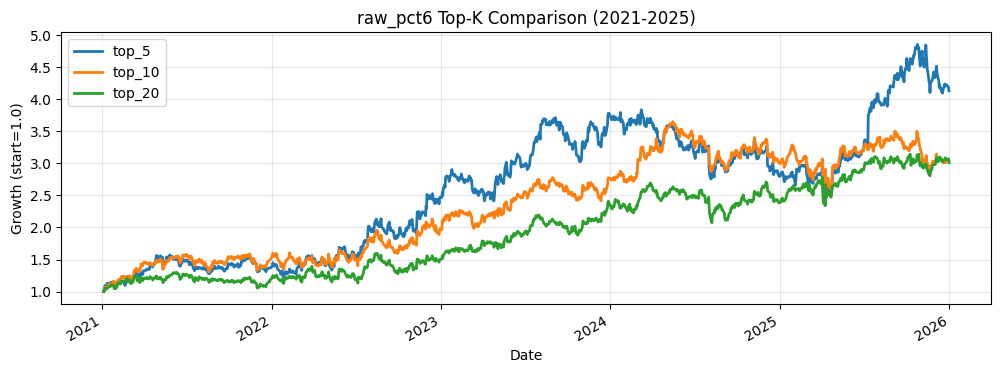

,top_5_equity,top_5_returns,top_10_equity,top_10_returns,top_20_equity,top_20_returns
date,,,,,,
2025-12-24,422290.571380,0.005445,303347.754680,0.009317,306855.112859,-0.005423
2025-12-26,421842.941269,-0.001060,304463.768422,0.003679,305866.426987,-0.003222
2025-12-29,419179.902663,-0.006313,304578.511190,0.000377,305980.831487,0.000374
2025-12-30,417969.240166,-0.002888,303276.421628,-0.004275,306772.989798,0.002589
2025-12-31,412850.485357,-0.012247,302837.576618,-0.001447,300882.977289,-0.019200


In [11]:
score_col = str(BENCHMARK_CFG["selection_score_col"])
component_cols = resolve_component_cols(score_col)
top_k_values = [int(k) for k in BENCHMARK_CFG.get("top_k_values", [5, 10, 20])]
strategy_runs = {}
comparison_rows = []

print(f"Strategy score: {score_col}")
print(f"Component columns: {component_cols}")
print(f"Component threshold: {BENCHMARK_CFG['component_threshold']}")

for top_k in top_k_values:
    run = run_top_k_buy_score_rule(
        panel=bt_panel_5y,
        score_col=score_col,
        component_cols=component_cols,
        component_threshold=float(BENCHMARK_CFG["component_threshold"]),
        price_col="close",
        top_k=int(top_k),
        rebalance_freq=BENCHMARK_CFG["rebalance_freq"],
        initial_balance=float(BENCHMARK_CFG["initial_balance"]),
        fee_bps=float(BENCHMARK_CFG["fee_bps"]),
        slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
    )
    summary = summarize_curve(run["returns"].rename("returns"), FROZEN_BT_YEARS, mode=f"raw_pct6_top_{top_k}")
    strategy_runs[int(top_k)] = {"run": run, "summary": summary}
    print(f"Yearly OOS results: top {top_k}")
    display(summary["yearly_df"])
    print(f"Executed trade counts: top {top_k}")
    display(run["executed_action_counts"].rename("count"))
    comparison_rows.append({
        "score_variant": "raw_pct6",
        "score_col": score_col,
        "mode": f"top_{top_k}",
        "total_return_pct": summary["total_return_pct"],
        "sharpe": summary["sharpe"],
        "max_drawdown_pct": summary["max_drawdown_pct"],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(["total_return_pct", "sharpe"], ascending=[False, False]).reset_index(drop=True)
print("raw_pct6 top-k comparison (combined OOS):")
display(comparison_df)

best_by_variant_df = comparison_df.head(1).copy()
print("Best top-k setting:")
display(best_by_variant_df)

reference_index = next(iter(strategy_runs.values()))["run"]["equity"].index
fig, ax = plt.subplots(figsize=(12, 4))
for top_k in top_k_values:
    eq = strategy_runs[int(top_k)]["run"]["equity"].rename("equity").reindex(reference_index).ffill()
    (eq / max(float(eq.iloc[0]), 1e-12)).plot(ax=ax, lw=2, label=f"top_{top_k}")
ax.set_title(f"raw_pct6 Top-K Comparison ({FROZEN_BT_YEARS[0]}-{FROZEN_BT_YEARS[-1]})")
ax.set_xlabel("Date")
ax.set_ylabel("Growth (start=1.0)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

tail_df = pd.DataFrame(index=reference_index)
for top_k in top_k_values:
    eq = strategy_runs[int(top_k)]["run"]["equity"].rename("equity").reindex(reference_index).ffill()
    ret = strategy_runs[int(top_k)]["run"]["returns"].rename("returns").reindex(reference_index).fillna(0.0)
    tail_df[f"top_{top_k}_equity"] = eq
    tail_df[f"top_{top_k}_returns"] = ret
display(tail_df.tail())


## J) Paper-Inspired Research Suite

This section treats the strategy as an open research question rather than assuming the current score is correct. Each block answers a different question inspired by time-series momentum, cross-sectional momentum, factor research, and characteristics-based ML research.

The goal is to separate timing, ranking quality, component roles, and portfolio construction so we can tell where any edge is really coming from.


In [12]:
# 9) Paper-inspired experiments: cross-sectional ranking, factor sleeves, ranking-vs-portfolio, sniper rules

PAPER_EXPERIMENT_CFG = {
    "cross_sectional_rebalance_freq": "M",
    "cross_sectional_forward_horizon_days": 21,
    "bucket_count": 5,
    "sniper_entry_threshold": 0.60,
    "sniper_exit_threshold": 0.40,
    "sniper_rebalance_freq": None,
}
print("Paper-inspired experiment config")
display(pd.DataFrame([PAPER_EXPERIMENT_CFG]))


def _pivot_panel(panel, col, symbols=None):
    working_symbols = sorted(panel.index.get_level_values("symbol").unique()) if symbols is None else list(symbols)
    return (
        panel[[col]]
        .reset_index()
        .pivot(index="date", columns="symbol", values=col)
        .reindex(columns=working_symbols)
        .sort_index()
    )


def _compute_cross_sectional_ranking_diagnostics(
    panel,
    *,
    score_col,
    variant_name,
    rebalance_freq,
    forward_horizon_days,
    bucket_count,
):
    symbols = sorted(panel.index.get_level_values("symbol").unique())
    close = _pivot_panel(panel, "close", symbols=symbols).replace([np.inf, -np.inf], np.nan).ffill()
    if score_col == "__momentum_21d__":
        score = close.pct_change(21)
    else:
        score = _pivot_panel(panel, score_col, symbols=symbols)
    score = score.shift(1).replace([np.inf, -np.inf], np.nan)
    forward_return = close.shift(-int(forward_horizon_days)).divide(close).subtract(1.0)
    common_dates = score.index.intersection(forward_return.index)
    rebalance_mask = make_rebalance_mask(common_dates, rebalance_freq)
    fold_rows = []
    bucket_rows = []

    for t, dt in enumerate(common_dates):
        if not bool(rebalance_mask[t]):
            continue
        aligned = pd.concat(
            {
                "score": pd.to_numeric(score.loc[dt], errors="coerce"),
                "forward_return": pd.to_numeric(forward_return.loc[dt], errors="coerce"),
            },
            axis=1,
        ).dropna()
        if len(aligned) < max(int(bucket_count) + 1, 8):
            continue
        aligned["bucket"] = np.ceil(
            aligned["score"].rank(method="first", pct=True) * float(bucket_count)
        ).clip(1, int(bucket_count)).astype(int)
        ic = aligned["score"].corr(aligned["forward_return"], method="spearman")
        top_bucket = aligned.loc[aligned["bucket"] == int(bucket_count), "forward_return"]
        bottom_bucket = aligned.loc[aligned["bucket"] == 1, "forward_return"]
        spread = float(top_bucket.mean() - bottom_bucket.mean()) if len(top_bucket) and len(bottom_bucket) else np.nan
        fold_rows.append(
            {
                "date": pd.Timestamp(dt),
                "variant_name": str(variant_name),
                "mean_spearman_ic": float(ic) if pd.notna(ic) else np.nan,
                "long_short_spread": spread,
                "top_bucket_forward_return": float(top_bucket.mean()) if len(top_bucket) else np.nan,
                "bottom_bucket_forward_return": float(bottom_bucket.mean()) if len(bottom_bucket) else np.nan,
                "symbols_ranked": int(len(aligned)),
            }
        )
        bucket_grouped = aligned.groupby("bucket", sort=True)["forward_return"].mean()
        for bucket_id, bucket_mean in bucket_grouped.items():
            bucket_rows.append(
                {
                    "variant_name": str(variant_name),
                    "bucket": int(bucket_id),
                    "mean_forward_return": float(bucket_mean),
                }
            )

    fold_df = pd.DataFrame(fold_rows)
    bucket_df = pd.DataFrame(bucket_rows)
    if fold_df.empty:
        summary_df = pd.DataFrame()
    else:
        summary_df = pd.DataFrame([
            {
                "variant_name": str(variant_name),
                "rebalance_freq": str(rebalance_freq),
                "forward_horizon_days": int(forward_horizon_days),
                "bucket_count": int(bucket_count),
                "mean_spearman_ic": float(fold_df["mean_spearman_ic"].mean()),
                "mean_long_short_spread": float(fold_df["long_short_spread"].mean()),
                "mean_top_bucket_forward_return": float(fold_df["top_bucket_forward_return"].mean()),
                "mean_bottom_bucket_forward_return": float(fold_df["bottom_bucket_forward_return"].mean()),
                "evaluation_dates": int(len(fold_df)),
                "mean_symbols_ranked": float(fold_df["symbols_ranked"].mean()),
            }
        ])
    if not bucket_df.empty:
        bucket_df = (
            bucket_df.groupby(["variant_name", "bucket"], as_index=False)["mean_forward_return"]
            .mean()
            .sort_values(["variant_name", "bucket"])
            .reset_index(drop=True)
        )
    return summary_df, bucket_df, fold_df




Paper-inspired experiment config


,cross_sectional_rebalance_freq,cross_sectional_forward_horizon_days,bucket_count,sniper_entry_threshold,sniper_exit_threshold,sniper_rebalance_freq
0,M,21,5,0.6,0.4,None


### J.1 Cross-Sectional Ranking Test

Question: do higher-scored names earn better forward returns than lower-scored names?

This is the closest analogue to cross-sectional momentum papers. It reports bucket forward returns, rank IC, and top-minus-bottom spread for `raw3`, `raw_pct6`, and a simple `21d` momentum baseline.


In [13]:
cross_sectional_specs = {
    "raw3": "buy_score_mean_raw3",
    "raw_pct6": "buy_score_mean_raw_pct6",
    "momentum_21d": "__momentum_21d__",
}
cs_summary_frames = []
cs_bucket_frames = []
cs_fold_frames = []
for variant_name, score_col in cross_sectional_specs.items():
    summary_df, bucket_df, fold_df = _compute_cross_sectional_ranking_diagnostics(
        bt_panel_5y,
        score_col=score_col,
        variant_name=variant_name,
        rebalance_freq=PAPER_EXPERIMENT_CFG["cross_sectional_rebalance_freq"],
        forward_horizon_days=int(PAPER_EXPERIMENT_CFG["cross_sectional_forward_horizon_days"]),
        bucket_count=int(PAPER_EXPERIMENT_CFG["bucket_count"]),
    )
    if not summary_df.empty:
        cs_summary_frames.append(summary_df)
    if not bucket_df.empty:
        cs_bucket_frames.append(bucket_df)
    if not fold_df.empty:
        cs_fold_frames.append(fold_df)

cs_summary_df = pd.concat(cs_summary_frames, ignore_index=True) if cs_summary_frames else pd.DataFrame()
cs_bucket_df = pd.concat(cs_bucket_frames, ignore_index=True) if cs_bucket_frames else pd.DataFrame()
cs_fold_df = pd.concat(cs_fold_frames, ignore_index=True) if cs_fold_frames else pd.DataFrame()
print("Cross-sectional momentum style ranking diagnostics")
display(cs_summary_df)
print("Cross-sectional bucket forward returns")
display(cs_bucket_df)




Cross-sectional momentum style ranking diagnostics


,variant_name,rebalance_freq,forward_horizon_days,bucket_count,mean_spearman_ic,mean_long_short_spread,mean_top_bucket_forward_return,mean_bottom_bucket_forward_return,evaluation_dates,mean_symbols_ranked
0,raw3,M,21,5,-0.028249,-0.000719,0.013582,0.014302,59,699.000000
1,raw_pct6,M,21,5,-0.017953,0.001589,0.014005,0.012416,59,699.000000
2,momentum_21d,M,21,5,0.019638,0.004859,0.017398,0.012539,58,722.775862


Cross-sectional bucket forward returns


,variant_name,bucket,mean_forward_return
0,raw3,1,0.014302
1,raw3,2,0.016836
2,raw3,3,0.017837
3,raw3,4,0.012490
4,raw3,5,0.013582
5,raw_pct6,1,0.012416
6,raw_pct6,2,0.016216
7,raw_pct6,3,0.016285
8,raw_pct6,4,0.016120
9,raw_pct6,5,0.014005


### J.2 Signal And Composite Role Test

Question: how should the model outputs be used?

`prob_buy` is treated as the direct signal, `pred_rf_reg` as a ranking modifier, and `ae_familiarity` as a confidence/filter term. This block tests whether simple role-aware composites are better than using the base signal alone.


In [14]:
factor_panel = bt_panel_5y.copy()
factor_panel["prob_buy_rankmod_rf"] = factor_panel[["prob_buy", "pred_rf_reg"]].mean(axis=1, skipna=True)
factor_panel["prob_buy_filter_ae"] = factor_panel["prob_buy"] * factor_panel["ae_familiarity"]
factor_panel["prob_buy_rankmod_rf_filter_ae"] = factor_panel[["prob_buy", "pred_rf_reg", "ae_familiarity"]].mean(axis=1, skipna=True)

factor_sleeve_specs = {
    "prob_buy_signal": "prob_buy",
    "prob_buy_plus_rf_rankmod": "prob_buy_rankmod_rf",
    "prob_buy_plus_ae_filter": "prob_buy_filter_ae",
    "prob_buy_plus_rf_plus_ae": "prob_buy_rankmod_rf_filter_ae",
    "raw3_factor": "buy_score_mean_raw3",
    "raw_pct6_factor": "buy_score_mean_raw_pct6",
}
factor_summary_frames = []
for variant_name, score_col in factor_sleeve_specs.items():
    summary_df, _, _ = _compute_cross_sectional_ranking_diagnostics(
        factor_panel,
        score_col=score_col,
        variant_name=variant_name,
        rebalance_freq=PAPER_EXPERIMENT_CFG["cross_sectional_rebalance_freq"],
        forward_horizon_days=int(PAPER_EXPERIMENT_CFG["cross_sectional_forward_horizon_days"]),
        bucket_count=int(PAPER_EXPERIMENT_CFG["bucket_count"]),
    )
    if not summary_df.empty:
        factor_summary_frames.append(summary_df)
factor_summary_df = pd.concat(factor_summary_frames, ignore_index=True) if factor_summary_frames else pd.DataFrame()
print("Fama-French style signal/composite diagnostics")
display(factor_summary_df)




Fama-French style signal/composite diagnostics


,variant_name,rebalance_freq,forward_horizon_days,bucket_count,mean_spearman_ic,mean_long_short_spread,mean_top_bucket_forward_return,mean_bottom_bucket_forward_return,evaluation_dates,mean_symbols_ranked
0,prob_buy_signal,M,21,5,-0.031421,-0.004592,0.011901,0.016494,59,699.0
1,prob_buy_plus_rf_rankmod,M,21,5,-0.036317,-0.001042,0.012562,0.013604,59,699.0
2,prob_buy_plus_ae_filter,M,21,5,-0.027798,-0.005304,0.011282,0.016585,59,699.0
3,prob_buy_plus_rf_plus_ae,M,21,5,-0.028249,-0.000719,0.013582,0.014302,59,699.0
4,raw3_factor,M,21,5,-0.028249,-0.000719,0.013582,0.014302,59,699.0
5,raw_pct6_factor,M,21,5,-0.017953,0.001589,0.014005,0.012416,59,699.0


### J.3 Portfolio Outcome Vs Ranking Quality

Question: is the winning portfolio rule actually backed by a better ranking signal, or is it just a lucky construction choice?

This block joins the best rule in each score family with the cross-sectional diagnostics so we can compare portfolio performance and ranking quality side by side.


In [15]:
characteristic_portfolio_diag_df = best_by_variant_df.merge(
    cs_summary_df[["variant_name", "mean_spearman_ic", "mean_long_short_spread", "mean_top_bucket_forward_return"]].rename(columns={"variant_name": "score_variant"}),
    on="score_variant",
    how="left",
)
print("Characteristics-factor style: portfolio outcome vs ranking quality")
display(characteristic_portfolio_diag_df)




Characteristics-factor style: portfolio outcome vs ranking quality


,score_variant,score_col,mode,total_return_pct,sharpe,max_drawdown_pct,mean_spearman_ic,mean_long_short_spread,mean_top_bucket_forward_return
0,raw_pct6,buy_score_mean_raw_pct6,top_5,312.850485,0.979616,-38.555627,-0.017953,0.001589,0.014005


### J.4 Strategy Focus

Question: which strategy variants are still active in this notebook after simplification?

This notebook now focuses only on the `raw_pct6` top-k strategy family, so the other strategy variants have been removed from the active comparisons.


In [16]:
def run_sniper_threshold_rule(
    *,
    panel,
    score_col,
    component_cols,
    entry_threshold,
    exit_threshold,
    price_col,
    rebalance_freq,
    initial_balance,
    fee_bps,
    slippage_bps,
):
    _ = rebalance_freq
    inputs = _prepare_capacity_rule_inputs(panel, score_col, component_cols, price_col)
    symbols = inputs["symbols"]
    common_dates = inputs["common_dates"]
    score = inputs["score"]
    prob_buy = inputs["prob_buy"]
    prob_short = inputs["prob_short"]
    close = inputs["close"]

    entry_ok = (score.notna() & np.isfinite(score) & close.gt(0.0)).fillna(False)
    exit_trigger = (~close.gt(0.0)).fillna(True)
    for col in inputs["component_cols"]:
        component = inputs["component_frames"][col]
        component_valid = component.notna() & np.isfinite(component)
        entry_ok &= (component.gt(float(entry_threshold)) & component_valid).fillna(False)
        exit_trigger |= ((~component_valid) | component.le(float(exit_threshold))).fillna(True)

    action_type = np.zeros((len(common_dates), len(symbols)), dtype=int)
    held_idx = set()
    symbol_to_idx = {sym: idx for idx, sym in enumerate(symbols)}
    position_by_day = pd.DataFrame(0, index=common_dates, columns=symbols, dtype=int)

    for t, dt in enumerate(common_dates):
        price_ok_t = close.loc[dt].gt(0.0)
        prob_buy_t = prob_buy.loc[dt]
        prob_short_t = prob_short.loc[dt]
        classifier_short = (prob_short_t > prob_buy_t).fillna(False)

        exit_idx = sorted(
            idx
            for idx in held_idx
            if bool(exit_trigger.loc[dt].iloc[idx])
            or (not np.isfinite(prob_buy_t.iloc[idx]))
            or (not np.isfinite(prob_short_t.iloc[idx]))
            or bool(classifier_short.iloc[idx])
        )
        if exit_idx:
            action_type[t, exit_idx] = 2
            held_idx -= set(exit_idx)

        candidate_mask = entry_ok.loc[dt] & price_ok_t
        ranked = score.loc[dt][candidate_mask].sort_values(ascending=False, kind="stable")
        enter_idx = []
        for sym in ranked.index:
            idx = symbol_to_idx[str(sym)]
            if idx in held_idx:
                continue
            enter_idx.append(idx)
        if enter_idx:
            action_type[t, enter_idx] = 1
            held_idx |= set(enter_idx)

        if held_idx:
            position_by_day.iloc[t, sorted(held_idx)] = 1

    eq, ret, cash, details = backtest_strategy_per_stock_discrete(
        action_type=action_type,
        close_by_day=close,
        eligible_by_day=close.gt(0.0).to_numpy(dtype=bool),
        buy_score_by_day=score.fillna(0.0).to_numpy(dtype=float),
        initial_balance=float(initial_balance),
        fee_bps=float(fee_bps),
        slippage_bps=float(slippage_bps),
        max_buys_per_day=None,
        rebalance_mask=None,
        return_execution_stats=True,
        return_trade_log=True,
    )
    cash = cash.mask(cash.abs() < 1e-9, 0.0)
    return {
        "equity": eq,
        "returns": ret,
        "cash": cash,
        "trade_log": details.get("trade_log", pd.DataFrame()),
        "executed_action_counts": pd.Series({
            "buy": int(details.get("executed_buy_count", 0)),
            "sell": int(details.get("executed_sell_count", 0)),
        }, dtype=int),
        "positions": position_by_day,
    }


active_strategy_df = pd.DataFrame(
    [
        {"strategy": "raw_pct6_top_5", "component_threshold": 0.50, "top_k": 5},
        {"strategy": "raw_pct6_top_10", "component_threshold": 0.50, "top_k": 10},
        {"strategy": "raw_pct6_top_20", "component_threshold": 0.50, "top_k": 20},
    ]
)
print("Active strategy set")
display(active_strategy_df)



Active strategy set


,strategy,component_threshold,top_k
0,raw_pct6_top_5,0.50,5
1,raw_pct6_top_10,0.50,10
2,raw_pct6_top_20,0.50,20


### J.5 raw_pct6 Top-K Sweep

Question: with the `raw_pct6` signal fixed, how sensitive are results to the portfolio capacity choice?

This block keeps the threshold fixed at `0.50` and compares only `top_k = 5`, `10`, and `20`.


In [17]:
raw_pct6_component_cols = resolve_component_cols("buy_score_mean_raw_pct6")
raw_pct6_topk_rows = []
for top_k in [5, 10, 20]:
    top_run = run_top_k_buy_score_rule(
        panel=bt_panel_5y,
        score_col="buy_score_mean_raw_pct6",
        component_cols=raw_pct6_component_cols,
        component_threshold=0.50,
        price_col="close",
        top_k=int(top_k),
        rebalance_freq=None,
        initial_balance=float(BENCHMARK_CFG["initial_balance"]),
        fee_bps=float(BENCHMARK_CFG["fee_bps"]),
        slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
    )
    top_summary = summarize_curve(top_run["returns"].rename("returns"), FROZEN_BT_YEARS, mode=f"raw_pct6_top_{top_k}")
    raw_pct6_topk_rows.append({
        "mode": f"top_{top_k}",
        "component_threshold": 0.50,
        "total_return_pct": top_summary["total_return_pct"],
        "sharpe": top_summary["sharpe"],
        "max_drawdown_pct": top_summary["max_drawdown_pct"],
        "buy_count": int(top_run["executed_action_counts"].get("buy", 0)),
        "sell_count": int(top_run["executed_action_counts"].get("sell", 0)),
    })
raw_pct6_topk_df = pd.DataFrame(raw_pct6_topk_rows).sort_values(
    ["total_return_pct", "sharpe"], ascending=[False, False]
).reset_index(drop=True)
print("raw_pct6 top-k sweep")
display(raw_pct6_topk_df)


raw_pct6 top-k sweep


,mode,component_threshold,total_return_pct,sharpe,max_drawdown_pct,buy_count,sell_count
0,top_5,0.50,312.850485,0.979616,-38.555627,491,488
1,top_10,0.50,202.837577,0.868357,-33.144988,751,746
2,top_20,0.50,200.882977,0.934673,-22.987897,1203,1192


### J.6 Confirmation Set

This section freezes a small top-k shortlist for the current `raw_pct6` strategy and evaluates those candidates on two slices of the same OOS block:

- `selection_years = 2021-2023`: the part of the OOS window we have implicitly been using to learn which ideas look promising
- `confirmation_years = 2024-2025`: a smaller confirmation slice used to check whether the short list still behaves well after we stop scanning large parameter grids

The candidates are intentionally fixed and small:

- `raw_pct6` daily `top_5` with component threshold `0.50`
- `raw_pct6` daily `top_10` with component threshold `0.50`
- `raw_pct6` daily `top_20` with component threshold `0.50`

This is still not a fully untouched out-of-sample test, but it is a cleaner confirmation step than continuing to optimize across the whole 2021-2025 window.


Confirmation experiment config


,selection_years,confirmation_years,candidate_count
0,2021-2023,2024-2025,3


Confirmation candidate summary


,candidate_name,kind,selection_total_return_pct,selection_sharpe,selection_max_drawdown_pct,confirmation_total_return_pct,confirmation_sharpe,confirmation_max_drawdown_pct,full_oos_total_return_pct,full_oos_sharpe,full_oos_max_drawdown_pct,buy_count,sell_count
0,raw_pct6_daily_top20_thr045,top_k,137.723210,1.147806,-19.958002,26.568616,0.583862,-22.987897,200.882977,0.934673,-22.987897,1203,1192
1,raw_pct6_daily_top5_thr045,top_k,277.890091,1.442338,-22.297711,9.251472,0.299449,-38.555627,312.850485,0.979616,-38.555627,491,488
2,raw_pct6_daily_top10_thr045,top_k,177.166153,1.240534,-18.497108,9.262106,0.296439,-33.144988,202.837577,0.868357,-33.144988,751,746


Confirmation candidate yearly breakdown


,mode,test_year,total_return_pct,sharpe,max_drawdown_pct,candidate_name,window
0,raw_pct6_daily_top10_thr045_confirmation,2024,8.219129,0.444244,-21.327887,raw_pct6_daily_top10_thr045,confirmation
1,raw_pct6_daily_top10_thr045_confirmation,2025,0.963765,0.202740,-25.765046,raw_pct6_daily_top10_thr045,confirmation
2,raw_pct6_daily_top20_thr045_confirmation,2024,0.345697,0.132192,-22.987897,raw_pct6_daily_top20_thr045,confirmation
3,raw_pct6_daily_top20_thr045_confirmation,2025,26.132579,0.963292,-16.004457,raw_pct6_daily_top20_thr045,confirmation
4,raw_pct6_daily_top5_thr045_confirmation,2024,-26.011699,-0.952895,-28.105084,raw_pct6_daily_top5_thr045,confirmation
5,raw_pct6_daily_top5_thr045_confirmation,2025,47.660468,1.133519,-21.023274,raw_pct6_daily_top5_thr045,confirmation
6,raw_pct6_daily_top10_thr045_selection,2021,51.975154,1.580431,-17.369593,raw_pct6_daily_top10_thr045,selection
7,raw_pct6_daily_top10_thr045_selection,2022,30.195397,0.880780,-18.497108,raw_pct6_daily_top10_thr045,selection
8,raw_pct6_daily_top10_thr045_selection,2023,40.078657,1.463112,-12.953600,raw_pct6_daily_top10_thr045,selection
9,raw_pct6_daily_top20_thr045_selection,2021,19.411242,0.810549,-18.453587,raw_pct6_daily_top20_thr045,selection


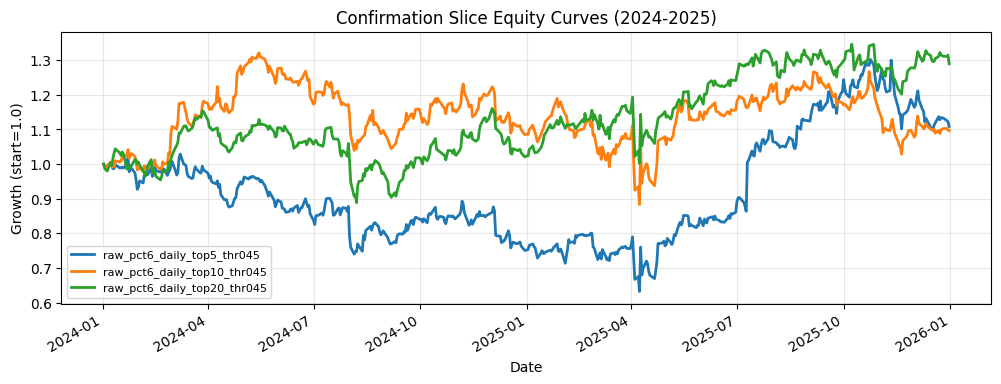

In [18]:
CONFIRMATION_CFG = {
    "selection_years": [2021, 2022, 2023],
    "confirmation_years": [2024, 2025],
}
print("Confirmation experiment config")
display(pd.DataFrame([{
    "selection_years": "2021-2023",
    "confirmation_years": "2024-2025",
    "candidate_count": 3,
}]))

confirmation_panel = bt_panel_5y.copy()
confirmation_candidates = [
    {
        "candidate_name": "raw_pct6_daily_top5_thr045",
        "kind": "top_k",
        "score_col": "buy_score_mean_raw_pct6",
        "component_cols": resolve_component_cols("buy_score_mean_raw_pct6"),
        "component_threshold": 0.50,
        "rebalance_freq": None,
        "top_k": 5,
    },
    {
        "candidate_name": "raw_pct6_daily_top10_thr045",
        "kind": "top_k",
        "score_col": "buy_score_mean_raw_pct6",
        "component_cols": resolve_component_cols("buy_score_mean_raw_pct6"),
        "component_threshold": 0.50,
        "rebalance_freq": None,
        "top_k": 10,
    },
    {
        "candidate_name": "raw_pct6_daily_top20_thr045",
        "kind": "top_k",
        "score_col": "buy_score_mean_raw_pct6",
        "component_cols": resolve_component_cols("buy_score_mean_raw_pct6"),
        "component_threshold": 0.50,
        "rebalance_freq": None,
        "top_k": 20,
    },
]


def _slice_returns(returns, years):
    year_set = {int(y) for y in years}
    return returns.loc[returns.index.year.map(int).isin(year_set)]


confirmation_rows = []
confirmation_yearly_frames = []
confirmation_curve_map = {}

for spec in confirmation_candidates:
    candidate_name = str(spec["candidate_name"])
    if spec["kind"] == "top_k":
        run = run_top_k_buy_score_rule(
            panel=confirmation_panel,
            score_col=str(spec["score_col"]),
            component_cols=list(spec.get("component_cols", [])),
            component_threshold=float(spec.get("component_threshold", 0.0)),
            price_col="close",
            top_k=int(spec["top_k"]),
            rebalance_freq=spec.get("rebalance_freq"),
            initial_balance=float(BENCHMARK_CFG["initial_balance"]),
            fee_bps=float(BENCHMARK_CFG["fee_bps"]),
            slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
        )
        returns = run["returns"].rename("returns")
        executed_counts = run.get("executed_action_counts", pd.Series(dtype=float))
    elif spec["kind"] == "sniper":
        run = run_sniper_threshold_rule(
            panel=confirmation_panel,
            score_col=str(spec["score_col"]),
            component_cols=list(spec.get("component_cols", [])),
            entry_threshold=float(spec["entry_threshold"]),
            exit_threshold=float(spec["exit_threshold"]),
            price_col="close",
            rebalance_freq=spec.get("rebalance_freq"),
            initial_balance=float(BENCHMARK_CFG["initial_balance"]),
            fee_bps=float(BENCHMARK_CFG["fee_bps"]),
            slippage_bps=float(BENCHMARK_CFG["slippage_bps"]),
        )
        returns = run["returns"].rename("returns")
        executed_counts = run.get("executed_action_counts", pd.Series(dtype=float))
    elif spec["kind"] == "benchmark":
        returns = bh_ret.rename("returns")
        executed_counts = pd.Series({"buy": np.nan, "sell": np.nan}, dtype=float)
    else:
        raise ValueError(f"Unsupported candidate kind: {spec['kind']}")

    full_summary = summarize_curve(returns, FROZEN_BT_YEARS, mode=candidate_name)
    selection_returns = _slice_returns(returns, CONFIRMATION_CFG["selection_years"])
    confirmation_returns = _slice_returns(returns, CONFIRMATION_CFG["confirmation_years"])
    selection_summary = summarize_curve(selection_returns, CONFIRMATION_CFG["selection_years"], mode=f"{candidate_name}_selection")
    confirmation_summary = summarize_curve(confirmation_returns, CONFIRMATION_CFG["confirmation_years"], mode=f"{candidate_name}_confirmation")

    confirmation_rows.append({
        "candidate_name": candidate_name,
        "kind": spec["kind"],
        "selection_total_return_pct": selection_summary["total_return_pct"],
        "selection_sharpe": selection_summary["sharpe"],
        "selection_max_drawdown_pct": selection_summary["max_drawdown_pct"],
        "confirmation_total_return_pct": confirmation_summary["total_return_pct"],
        "confirmation_sharpe": confirmation_summary["sharpe"],
        "confirmation_max_drawdown_pct": confirmation_summary["max_drawdown_pct"],
        "full_oos_total_return_pct": full_summary["total_return_pct"],
        "full_oos_sharpe": full_summary["sharpe"],
        "full_oos_max_drawdown_pct": full_summary["max_drawdown_pct"],
        "buy_count": executed_counts.get("buy", np.nan),
        "sell_count": executed_counts.get("sell", np.nan),
    })

    selection_yearly = selection_summary["yearly_df"].assign(candidate_name=candidate_name, window="selection")
    confirmation_yearly = confirmation_summary["yearly_df"].assign(candidate_name=candidate_name, window="confirmation")
    confirmation_yearly_frames.extend([selection_yearly, confirmation_yearly])
    confirmation_curve_map[candidate_name] = confirmation_returns

confirmation_summary_df = pd.DataFrame(confirmation_rows).sort_values(
    ["confirmation_sharpe", "confirmation_total_return_pct"],
    ascending=[False, False],
).reset_index(drop=True)
confirmation_yearly_df = pd.concat(confirmation_yearly_frames, ignore_index=True) if confirmation_yearly_frames else pd.DataFrame()

print("Confirmation candidate summary")
display(confirmation_summary_df)
print("Confirmation candidate yearly breakdown")
display(confirmation_yearly_df.sort_values(["window", "candidate_name", "test_year"]).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(12, 4))
for candidate_name, candidate_returns in confirmation_curve_map.items():
    if len(candidate_returns) == 0:
        continue
    candidate_equity = (1.0 + candidate_returns).cumprod()
    candidate_equity = candidate_equity / max(float(candidate_equity.iloc[0]), 1e-12)
    candidate_equity.plot(ax=ax, lw=2, label=candidate_name)
ax.set_title("Confirmation Slice Equity Curves (2024-2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Growth (start=1.0)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.show()
